# Unsupervised Weather Regime Characterization and Data Stratification

## 1. Executive Summary & Problem Diagnosis
During initial training phases of the CNN radar nowcasting system, an architectural anomaly was observed: **validation loss was consistently lower than training loss**. 

To isolate the root cause, a dataset-swapping experiment was conducted. Swapping the training and validation configurations inverted this behavior, proving that a severe **meteorological distribution shift** was present across the naïve data partitions. The training split was heavily weighted with intense summer convective systems, while the validation split was dominated by simpler, uniform winter stratiform rain or completely dry periods.

### The Production Solution
To ensure stable validation benchmarks and reliable model comparisons, an automated archive characterization pipeline was implemented (`src/data/characterize_archives.py`). Instead of manual partitioning or random calendar splits, this module:
1. Streams preprocessed `.npy` arrays with memory-mapped low-RAM overhead.
2. Inverts the `log1p` preprocessing transformations to recover true physical rain rates ($\text{mm/h}$).
3. Extracts a **9-dimensional meteorological feature descriptor vector** natively on the GPU.
4. Uses **Unsupervised K-Means Clustering** directly in the feature space to group data into real weather regimes.
5. Performs **Stratified Proportional Sampling** to build completely balanced data partitions (`train`/`val`/`test`).


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting configs
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100
})

# Path to the data-driven stratification mapping
metadata_path = Path("../data/difficulty/NW/showcase/dataset_difficulty_metadata.csv")

if not metadata_path.exists():
    raise FileNotFoundError(
        f"Metadata matrix not found at {metadata_path}. "
        "Please run `make stratify` from the repository root first to compute the feature space."
    )

df = pd.read_csv(metadata_path)
print(f"[✓] Metadata framework loaded successfully. Total archives cataloged: {len(df)}")
df.head()


[✓] Metadata framework loaded successfully. Total archives cataloged: 108


,rain_coverage_light,rain_coverage_moderate,rain_coverage_heavy,mean_intensity,max_intensity,spatial_variance,temporal_variability,average_motion,rainy_frames_count,archive_name,relative_path,total_frames,missing_data_ratio,weather_regime_cluster,computed_difficulty_score,split
0,0.210460,0.005803,0.000113,1.270270,123.787849,0.721129,0.246586,3.867595,2862,rainfall_NW_2016_01.1.npz,data/processed/NW/resize256x256_log_clip1500/r...,2880,0.000000,1,0.654751,train
1,0.108122,0.002784,0.000054,1.132330,168.195023,0.346833,0.125171,4.431581,2433,rainfall_NW_2016_01.2.npz,data/processed/NW/resize256x256_log_clip1500/r...,2879,0.000347,1,0.423839,train
2,0.134791,0.002071,0.000020,1.027911,111.983429,0.263550,0.095936,4.766291,1965,rainfall_NW_2016_01.3.npz,data/processed/NW/resize256x256_log_clip1500/r...,3168,0.000000,1,0.365776,train
3,0.129689,0.004449,0.000117,1.289000,102.209862,0.538079,0.176487,4.301710,2187,rainfall_NW_2016_02.1.npz,data/processed/NW/resize256x256_log_clip1500/r...,2880,0.000000,1,0.496367,val
4,0.131840,0.002404,0.000054,1.039981,179.999969,0.376052,0.110301,4.192262,2397,rainfall_NW_2016_02.2.npz,data/processed/NW/resize256x256_log_clip1500/r...,2879,0.000347,1,0.432583,train


## 2. Statistical Exploration of the Weather Descriptor Space
Rather than letting a single arbitrary metric define data complexity, the characterization pipeline maps each 10-day archive block across 9 distinct meteorological dimensions. The distributions of the key dimensions are structured as follows:
- **Rain Coverage (00 vs 20):** The structural sparsity of weather systems is tracked (widespread stratiform fronts vs. isolated convective cells).
- **Temporal Variability (MAD):** Frame-to-frame Mean Absolute Difference is measured. High variability flags rapidly developing or dissipating cells.
- **Average Motion (Centroid Velocity):** The overall advection speed of the system is tracked by measuring the Euclidean displacement of the spatial centers of mass across frames.

**Note**: The cutoff values for light, moderate and heavy rain coverage are configurable in `stratify.yml`. The same is true for many more parameters that are used during stratification.


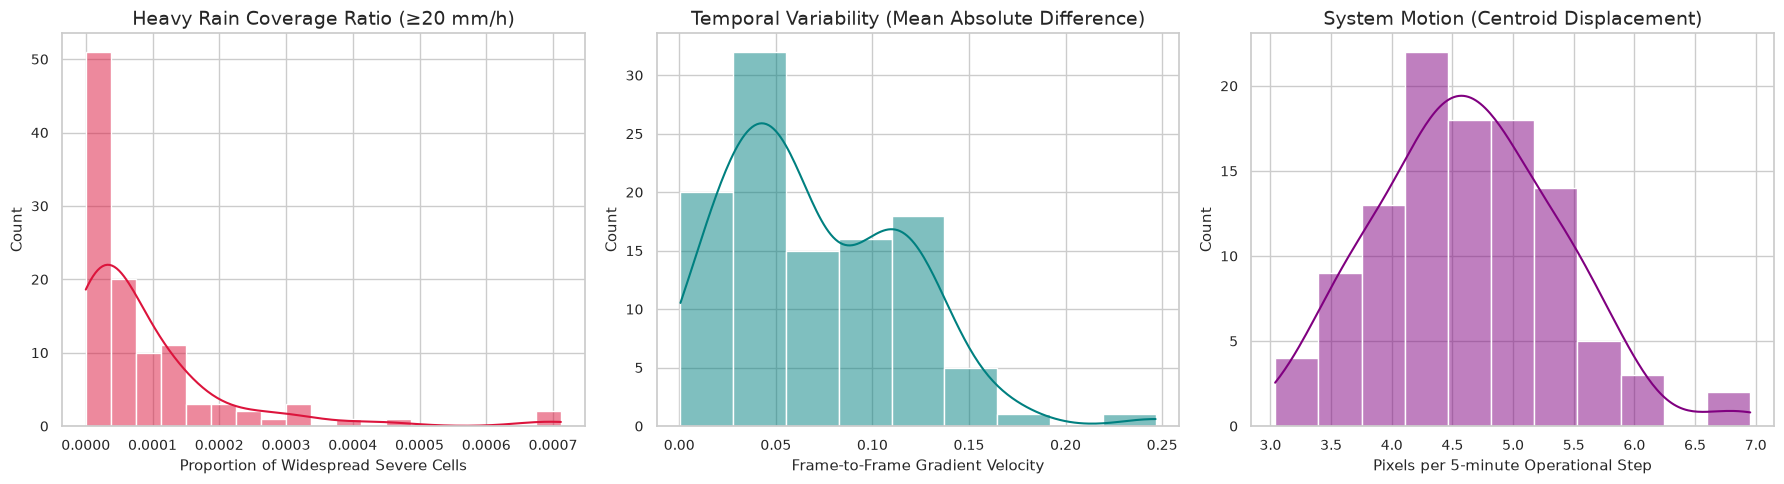

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Convective Tail Space
sns.histplot(df["rain_coverage_heavy"], kde=True, color="crimson", ax=axes[0])
axes[0].set_title("Heavy Rain Coverage Ratio (≥20 mm/h)")
axes[0].set_xlabel("Proportion of Widespread Severe Cells")

# Plot 2: Fluid Dynamics Flux
sns.histplot(df["temporal_variability"], kde=True, color="teal", ax=axes[1])
axes[1].set_title("Temporal Variability (Mean Absolute Difference)")
axes[1].set_xlabel("Frame-to-Frame Gradient Velocity")

# Plot 3: Advection Translation Speeds
sns.histplot(df["average_motion"], kde=True, color="purple", ax=axes[2])
axes[2].set_title("System Motion (Centroid Displacement)")
axes[2].set_xlabel("Pixels per 5-minute Operational Step")

plt.tight_layout()
plt.show()


## 3. Unsupervised Pattern Discovery via K-Means Clustering
To separate these blocks without human bias, the 9-dimensional standardized feature space (`StandardScaler`) is passed directly into a **K-Means Clustering** engine. 

To ensure the code remains human-readable and clean, a unified continuous **Difficulty Score** is automatically calculated by the script, and the cluster labels are sorted monotonically against this score. This forces the groups into predictable, physics-driven categories:
*   **Cluster 0:** Low Intensity, Low Motion, Low Variability $\rightarrow$ **Light Winter Stratiform Fronts**
*   **Cluster 1:** High Spatial Footprint, Medium Variability $\rightarrow$ **Widespread Dynamic Frontal Systems**
*   **Cluster 2:** Severe Intensity Peaks, High Temporal Flux $\rightarrow$ **Severe Isolated Summer Convective Regimes**


/tmp/ipykernel_96157/3059611742.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


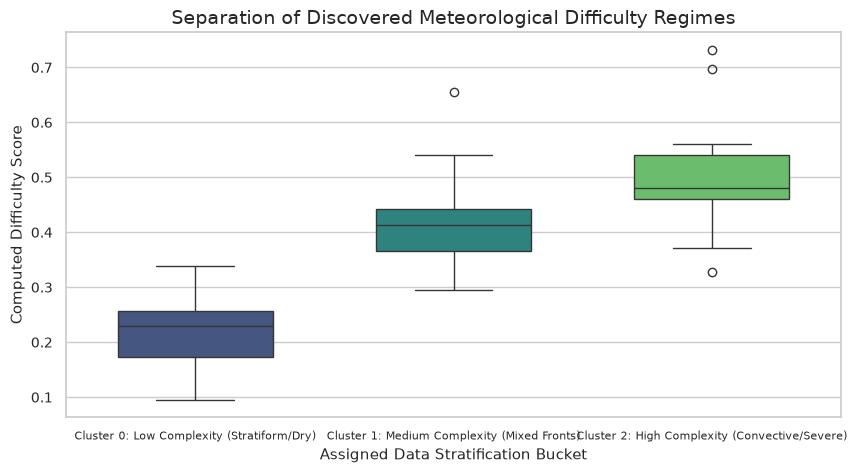

In [3]:
# Map cluster integers back to their physics-based descriptions
regime_labels = {
    0: "Cluster 0: Low Complexity (Stratiform/Dry)", 
    1: "Cluster 1: Medium Complexity (Mixed Fronts)", 
    2: "Cluster 2: High Complexity (Convective/Severe)"
}
df["Weather Regime Profile"] = df["weather_regime_cluster"].map(regime_labels)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df, 
    x="Weather Regime Profile", 
    y="computed_difficulty_score", 
    order=[regime_labels[0], regime_labels[1], regime_labels[2]],
    palette="viridis",
    width=0.6
)
plt.tick_params(axis='x', labelsize=8)
plt.title("Separation of Discovered Meteorological Difficulty Regimes")
plt.ylabel("Computed Difficulty Score")
plt.xlabel("Assigned Data Stratification Bucket")
plt.show()


## 4. Assessing Meteorological Parity (Reducing Split Domain Shift)
To confirm the stratification strategy successfully reduced the distribution shift, a 2D **Meteorological Parity Space** is constructed. 

By plotting **Total Rain Coverage** against **Convective Tail Severity**, the uniformity of the `train`, `val`, and `test` split assignments can be verified across all three difficulty clusters. Perfect overlap suggests the model is trained and evaluated on equivalent weather distributions.


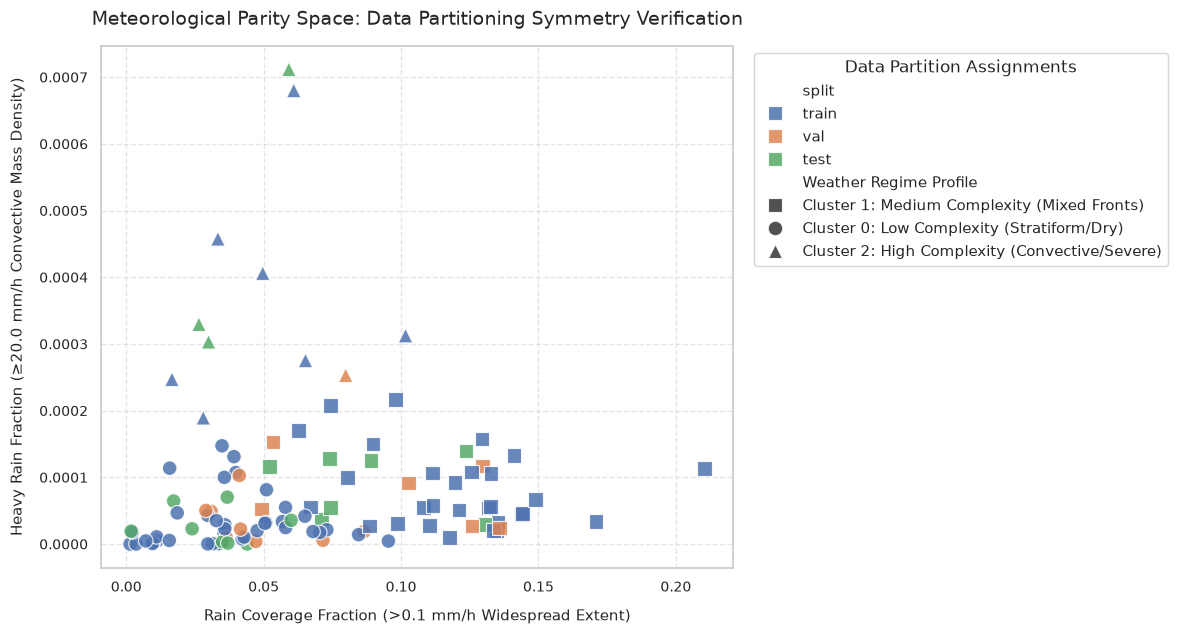

In [4]:
plt.figure(figsize=(12, 6.5))

# Overlay split partitions on top of the discovered physical clusters
sns.scatterplot(
    data=df, 
    x="rain_coverage_light", 
    y="rain_coverage_heavy", 
    hue="split", 
    style="Weather Regime Profile",
    palette={"train": "#4C72B0", "val": "#DD8452", "test": "#55A868"},
    markers={"Cluster 0: Low Complexity (Stratiform/Dry)": "o", "Cluster 1: Medium Complexity (Mixed Fronts)": "s", "Cluster 2: High Complexity (Convective/Severe)": "^"},
    s=110,
    alpha=0.85
)

plt.title("Meteorological Parity Space: Data Partitioning Symmetry Verification", pad=15)
plt.xlabel("Rain Coverage Fraction (>0.1 mm/h Widespread Extent)", labelpad=10)
plt.ylabel("Heavy Rain Fraction (≥20.0 mm/h Convective Mass Density)", labelpad=10)
plt.legend(title="Data Partition Assignments", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


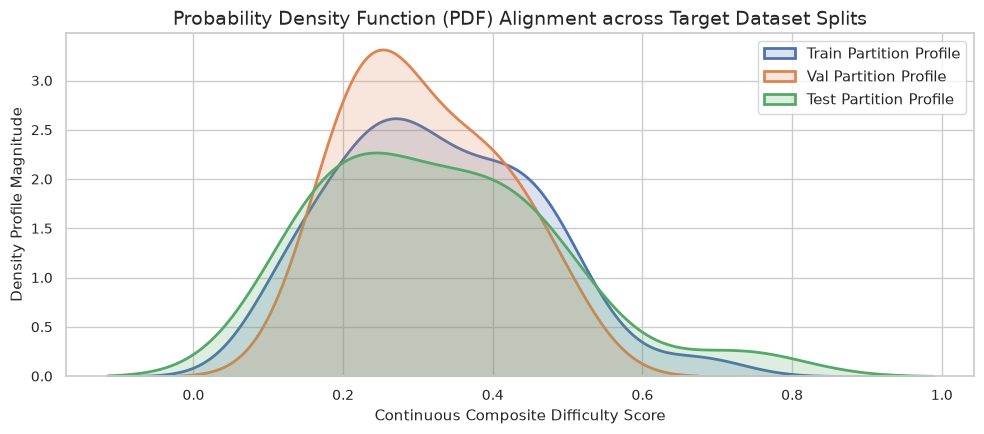

In [5]:
plt.figure(figsize=(10, 4.5))

# Plot the distribution density curves of the continuous difficulty metric per partition
for split_name, color_hex in [("train", "#4C72B0"), ("val", "#DD8452"), ("test", "#55A868")]:
    sns.kdeplot(
        df[df["split"] == split_name]["computed_difficulty_score"], 
        label=f"{split_name.capitalize()} Partition Profile", 
        fill=True, 
        color=color_hex, 
        alpha=0.20,
        linewidth=2
    )

plt.title("Probability Density Function (PDF) Alignment across Target Dataset Splits")
plt.xlabel("Continuous Composite Difficulty Score")
plt.ylabel("Density Profile Magnitude")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


## 5. Quantitative Verification Summary
The final averaged dataset properties are aggregated below per partition. By utilizing high-dimensional sampling, the values across `train`, `val`, and `test` act as statistical reflections of one another, thereby minimizing the potential for artificial baseline bias.


In [6]:
summary_report = df.groupby("split").agg(
    block_count=("archive_name", "count"),
    avg_diff_score=("computed_difficulty_score", "mean"),
    light_rain_cov=("rain_coverage_light", "mean"),
    heavy_convect_cov=("rain_coverage_heavy", "mean"),
    mean_intensity_val=("mean_intensity", "mean"),
    max_intensity_val=("max_intensity", "mean"),
    temporal_variability_mad=("temporal_variability", "mean"),
    system_motion_velocity=("average_motion", "mean")
).reindex(["train", "val", "test"])

summary_report.style.background_gradient(cmap="Blues", subset=["avg_diff_score", "heavy_convect_cov", "temporal_variability_mad"])


,block_count,avg_diff_score,light_rain_cov,heavy_convect_cov,mean_intensity_val,max_intensity_val,temporal_variability_mad,system_motion_velocity
split,,,,,,,,
train,74,0.324938,0.071126,0.000083,1.157956,126.206646,0.070890,4.609927
val,15,0.308223,0.070695,0.000065,1.122014,114.321735,0.072505,4.591371
test,19,0.328617,0.053685,0.000115,1.332459,133.781465,0.065052,4.731199


### Key Insights
* **Mitigation of Distribution Shift:** The validation dataset no longer represents a simplified subset of the data. Instead, it closely reflects the meteorological complexity of the training set, which may yield more representative and reliable training curves.
* **Accelerated Data Engineering Pipeline:** By analyzing preprocessed data in memory-mapped chunks directly on the GPU, 9 spatial features were extracted across 108 high-resolution tracking tracks in under three minutes, demonstrating substantial pipeline acceleration.


## 6. Configurable Search Engine: Identifying Distribution-Matched Meteorological Trios (Train/Val/Test)

Because the production sliding-window data loader requires continuous temporal blocks (e.g., `start_date` to `end_date`), randomly scattered files cannot be passed directly to the model. 

To preserve the integrity of the data stratification without altering the training or evaluation pipelines, a multi-window rolling search engine is implemented in this section. The distribution of weather clusters across a multi-year timeline is analyzed to programmatically identify a continuous **Training window, Validation window, and Testing window of fully configurable sizes** that share closely matching cluster ratios. This approach is intended to satisfy the stratification objectives while mitigating the risk of chronological bleeding or data leaks.


In [7]:
import calendar
# Configuration boundaries
TARGET_TRAIN_MONTHS = 9   # Scale the downsampled training duration
TARGET_VAL_MONTHS = 3     # Scale the validation verification window
TARGET_TEST_MONTHS = 3    # Scale the final testing window

# 1. Parse dates and aggregate files into clean monthly buckets
df['month_str'] = df['archive_name'].str.extract(r'rainfall_NW_(\d{4}_\d{2})')
df['month_date'] = pd.to_datetime(df['month_str'], format='%Y_%m')

# Pivot the data to get an explicit breakdown of cluster counts per calendar month
monthly_clusters = pd.crosstab(df['month_date'], df['weather_regime_cluster'])
all_months = pd.date_range(start=monthly_clusters.index.min(), end=monthly_clusters.index.max(), freq='MS')
monthly_clusters = monthly_clusters.reindex(all_months, fill_value=0)

# Compute the true mean difficulty score per calendar month
monthly_difficulty = df.groupby('month_date')['computed_difficulty_score'].mean().reindex(all_months, fill_value=0)

print(f"[*] Cataloged historical matrix spans from {monthly_clusters.index.min().strftime('%Y-%m')} to {monthly_clusters.index.max().strftime('%Y-%m')}")
print(f"[*] Search profile set: Train ({TARGET_TRAIN_MONTHS}m) | Val ({TARGET_VAL_MONTHS}m) | Test ({TARGET_TEST_MONTHS}m)\n")

# Compute rolling cluster distributions for the target sizes
rolling_train = monthly_clusters.rolling(window=TARGET_TRAIN_MONTHS).sum().dropna()
rolling_val = monthly_clusters.rolling(window=TARGET_VAL_MONTHS).sum().dropna()
rolling_test = monthly_clusters.rolling(window=TARGET_TEST_MONTHS).sum().dropna()

# Compute rolling average difficulty scores for each window
rolling_train_diff = monthly_difficulty.rolling(window=TARGET_TRAIN_MONTHS).mean().dropna()
rolling_val_diff = monthly_difficulty.rolling(window=TARGET_VAL_MONTHS).mean().dropna()
rolling_test_diff = monthly_difficulty.rolling(window=TARGET_TEST_MONTHS).mean().dropna()

# Normalize distributions into percentages so different window sizes match perfectly
train_pcts = rolling_train.div(rolling_train.sum(axis=1) + 1e-6, axis=0)
val_pcts = rolling_val.div(rolling_val.sum(axis=1) + 1e-6, axis=0)
test_pcts = rolling_test.div(rolling_test.sum(axis=1) + 1e-6, axis=0)

# Triple-loop search sweep to compute distribution and difficulty distance profiles
match_records = []

for t_end, t_profile in train_pcts.iterrows():
    t_start = t_end - pd.DateOffset(months=TARGET_TRAIN_MONTHS - 1)
    t_diff_val = rolling_train_diff.loc[t_end]
    
    for v_end, v_profile in val_pcts.iterrows():
        v_start = v_end - pd.DateOffset(months=TARGET_VAL_MONTHS - 1)
        v_diff_val = rolling_val_diff.loc[v_end]
        
        # skip if Train and Val overlap
        if (t_start <= v_end and v_start <= t_end):
            continue
            
        for ts_end, ts_profile in test_pcts.iterrows():
            ts_start = ts_end - pd.DateOffset(months=TARGET_TEST_MONTHS - 1)
            ts_diff_val = rolling_test_diff.loc[ts_end]
            
            # Ensure no combination of Train, Val, or Test windows overlap
            if (t_start <= ts_end and ts_start <= t_end) or (v_start <= ts_end and ts_start <= v_end):
                continue
            
            # Calculate total cross-split discrepancy score (Sum of Absolute Errors across all pairs)
            mae_tv = np.mean(np.abs(t_profile.values - v_profile.values))
            mae_tt = np.mean(np.abs(t_profile.values - ts_profile.values))
            mae_vt = np.mean(np.abs(v_profile.values - ts_profile.values))
            total_discrepancy = mae_tv + mae_tt + mae_vt
            
            # Calculate continuous difficulty score divergence across splits
            diff_mae_tv = abs(t_diff_val - v_diff_val)
            diff_mae_tt = abs(t_diff_val - ts_diff_val)
            diff_mae_vt = abs(v_diff_val - ts_diff_val)
            total_difficulty_error = diff_mae_tv + diff_mae_tt + diff_mae_vt
            
            match_records.append({
                "mae_score": total_discrepancy,
                "difficulty_error": total_difficulty_error,
                "train_range": f"{t_start.strftime('%Y-%m')} -> {t_end.strftime('%Y-%m')}",
                "val_range": f"{v_start.strftime('%Y-%m')} -> {v_end.strftime('%Y-%m')}",
                "test_range": f"{ts_start.strftime('%Y-%m')} -> {ts_end.strftime('%Y-%m')}",
                
                # Flattening individual cluster tracking indices directly into table columns
                "T_C0": round(t_profile.get(0, 0.0), 2),
                "T_C1": round(t_profile.get(1, 0.0), 2),
                "T_C2": round(t_profile.get(2, 0.0), 2),
                
                "V_C0": round(v_profile.get(0, 0.0), 2),
                "V_C1": round(v_profile.get(1, 0.0), 2),
                "V_C2": round(v_profile.get(2, 0.0), 2),
                
                "TS_C0": round(ts_profile.get(0, 0.0), 2),
                "TS_C1": round(ts_profile.get(1, 0.0), 2),
                "TS_C2": round(ts_profile.get(2, 0.0), 2),
                
                "train_avg_diff": round(t_diff_val, 3),
                "val_avg_diff": round(v_diff_val, 3),
                "test_avg_diff": round(ts_diff_val, 3)
            })

# Sort by cluster layout error first, then break ties using absolute difficulty score drift
rankings_df = pd.DataFrame(match_records).sort_values(by=["mae_score", "difficulty_error"]).reset_index(drop=True)

print(f"[✓] Scanned {len(rankings_df)} valid non-overlapping combination trios.")
print("\nTOP 20 OPTIMIZED METEOROLOGICAL TRIO CONFIGURATIONS (TIE-BROKEN BY DIFFICULTY SCALES):")

# Render explicit cluster columns next to the date ranges
table_columns = [
    "mae_score", "difficulty_error", 
    "train_range", "T_C0", "T_C1", "T_C2",
    "val_range", "V_C0", "V_C1", "V_C2",
    "test_range", "TS_C0", "TS_C1", "TS_C2"
]
rankings_df.head(20)[table_columns]



[*] Cataloged historical matrix spans from 2016-01 to 2018-12
[*] Search profile set: Train (9m) | Val (3m) | Test (3m)

[✓] Scanned 12144 valid non-overlapping combination trios.

TOP 20 OPTIMIZED METEOROLOGICAL TRIO CONFIGURATIONS (TIE-BROKEN BY DIFFICULTY SCALES):


,mae_score,difficulty_error,train_range,T_C0,T_C1,T_C2,val_range,V_C0,V_C1,V_C2,test_range,TS_C0,TS_C1,TS_C2
0,0.098765,0.009474,2016-10 -> 2017-06,0.63,0.30,0.07,2017-09 -> 2017-11,0.67,0.33,0.0,2018-09 -> 2018-11,0.67,0.33,0.0
1,0.098765,0.009474,2016-10 -> 2017-06,0.63,0.30,0.07,2018-09 -> 2018-11,0.67,0.33,0.0,2017-09 -> 2017-11,0.67,0.33,0.0
2,0.098765,0.024394,2016-09 -> 2017-05,0.67,0.26,0.07,2017-09 -> 2017-11,0.67,0.33,0.0,2018-09 -> 2018-11,0.67,0.33,0.0
3,0.098765,0.024394,2016-09 -> 2017-05,0.67,0.26,0.07,2018-09 -> 2018-11,0.67,0.33,0.0,2017-09 -> 2017-11,0.67,0.33,0.0
4,0.148148,0.036568,2016-03 -> 2016-11,0.59,0.30,0.11,2017-09 -> 2017-11,0.67,0.33,0.0,2018-09 -> 2018-11,0.67,0.33,0.0
5,0.148148,0.036568,2016-03 -> 2016-11,0.59,0.30,0.11,2018-09 -> 2018-11,0.67,0.33,0.0,2017-09 -> 2017-11,0.67,0.33,0.0
6,0.148148,0.040177,2016-02 -> 2016-10,0.59,0.30,0.11,2017-09 -> 2017-11,0.67,0.33,0.0,2018-09 -> 2018-11,0.67,0.33,0.0
7,0.148148,0.040177,2016-02 -> 2016-10,0.59,0.30,0.11,2018-09 -> 2018-11,0.67,0.33,0.0,2017-09 -> 2017-11,0.67,0.33,0.0
8,0.148148,0.044130,2016-03 -> 2016-11,0.59,0.30,0.11,2017-01 -> 2017-03,0.67,0.33,0.0,2017-09 -> 2017-11,0.67,0.33,0.0
9,0.148148,0.044130,2016-03 -> 2016-11,0.59,0.30,0.11,2017-01 -> 2017-03,0.67,0.33,0.0,2018-09 -> 2018-11,0.67,0.33,0.0


In [8]:
import calendar

# 1. Standard Pure Recommendation (Absolute Mathematical Minimum Error)
best_match_pure = rankings_df.iloc[0]

# 2. Data-Diversity Recommendation (Forced Cluster Presence Check)
diverse_condition = (
    (rankings_df["T_C0"] > 0.0) & (rankings_df["T_C1"] > 0.0) & (rankings_df["T_C2"] > 0.0) &
    (rankings_df["V_C0"] > 0.0) & (rankings_df["V_C1"] > 0.0) & (rankings_df["V_C2"] > 0.0) &
    (rankings_df["TS_C0"] > 0.0) & (rankings_df["TS_C1"] > 0.0) & (rankings_df["TS_C2"] > 0.0)
)
diverse_candidates = rankings_df[diverse_condition].reset_index(drop=True)

# Helper function to dynamically resolve exact month-end dates and print YAML blocks
def print_override_block(title_prefix, best_match):
    print("=" * 80)
    print(f"{title_prefix}")
    print("=" * 80)
    print(f"Cluster Distribution Error (Sum of Cluster MAE):  {best_match['mae_score']:.4f}")
    print(f"Intensity Divergence Error (Sum of Difficulty MAE): {best_match['difficulty_error']:.4f}")
    print("-" * 80)
    
    # Process ranges cleanly into YYYY and MM chunks
    t_start_yr, t_start_mo = map(int, best_match['train_range'].split(' -> ')[0].split('-'))
    t_end_yr, t_end_mo = map(int, best_match['train_range'].split(' -> ')[1].split('-'))
    
    v_start_yr, v_start_mo = map(int, best_match['val_range'].split(' -> ')[0].split('-'))
    v_end_yr, v_end_mo = map(int, best_match['val_range'].split(' -> ')[1].split('-'))
    
    ts_start_yr, ts_start_mo = map(int, best_match['test_range'].split(' -> ')[0].split('-'))
    ts_end_yr, ts_end_mo = map(int, best_match['test_range'].split(' -> ')[1].split('-'))
    
    # Dynamically calculate the exact last day of each target month
    # calendar.monthrange returns (first_day_weekday, number_of_days_in_month)
    t_last_day = calendar.monthrange(t_end_yr, t_end_mo)[1]
    v_last_day = calendar.monthrange(v_end_yr, v_end_mo)[1]
    ts_last_day = calendar.monthrange(ts_end_yr, ts_end_mo)[1]
    
    print(f"TRAIN INTERVAL SETTINGS:\n  train_start: \"{t_start_yr:04d}-{t_start_mo:02d}-01T00:00\"")
    print(f"  train_end:   \"{t_end_yr:04d}-{t_end_mo:02d}-{t_last_day:02d}T23:55\"")
    print(f"  Cluster Density Map: [C0: {best_match['T_C0']}, C1: {best_match['T_C1']}, C2: {best_match['T_C2']}] | Mean Difficulty: {best_match['train_avg_diff']}")
    print("-" * 80)
    print(f"VAL INTERVAL SETTINGS:\n  val_start: \"{v_start_yr:04d}-{v_start_mo:02d}-01T00:00\"")
    print(f"  val_end:   \"{v_end_yr:04d}-{v_end_mo:02d}-{v_last_day:02d}T23:55\"")
    print(f"  Cluster Density Map: [C0: {best_match['V_C0']}, C1: {best_match['V_C1']}, C2: {best_match['V_C2']}] | Mean Difficulty: {best_match['val_avg_diff']}")
    print("-" * 80)
    print(f"TEST INTERVAL SETTINGS:\n  test_start: \"{ts_start_yr:04d}-{ts_start_mo:02d}-01T00:00\"")
    print(f"  test_end:   \"{ts_end_yr:04d}-{ts_end_mo:02d}-{ts_last_day:02d}T23:55\"")
    print(f"  Cluster Density Map: [C0: {best_match['TS_C0']}, C1: {best_match['TS_C1']}, C2: {best_match['TS_C2']}] | Mean Difficulty: {best_match['test_avg_diff']}")
    print("=" * 80)
    print("\n")


# Execute the prints
print_override_block("OPTION A: ABSOLUTE MATHEMATICAL MINIMUM ERROR CONFIGURATION", best_match_pure)

if not diverse_candidates.empty:
    best_match_diverse = diverse_candidates.iloc[0]
    print_override_block("OPTION B: OPTIMIZED CONFIGURATION WITH GUARANTEED CLUSTER DIVERSITY (ALL SPLITS)", best_match_diverse)
else:
    print("=" * 80)
    print("WARNING: No trios found where ALL splits contain ALL 3 clusters simultaneously.")
    print("Consider scaling up TARGET_TRAIN_MONTHS or window scopes to allow complete cluster coverage.")
    print("=" * 80)


OPTION A: ABSOLUTE MATHEMATICAL MINIMUM ERROR CONFIGURATION
Cluster Distribution Error (Sum of Cluster MAE):  0.0988
Intensity Divergence Error (Sum of Difficulty MAE): 0.0095
--------------------------------------------------------------------------------
TRAIN INTERVAL SETTINGS:
  train_start: "2016-10-01T00:00"
  train_end:   "2017-06-30T23:55"
  Cluster Density Map: [C0: 0.63, C1: 0.3, C2: 0.07] | Mean Difficulty: 0.281
--------------------------------------------------------------------------------
VAL INTERVAL SETTINGS:
  val_start: "2017-09-01T00:00"
  val_end:   "2017-11-30T23:55"
  Cluster Density Map: [C0: 0.67, C1: 0.33, C2: 0.0] | Mean Difficulty: 0.285
--------------------------------------------------------------------------------
TEST INTERVAL SETTINGS:
  test_start: "2018-09-01T00:00"
  test_end:   "2018-11-30T23:55"
  Cluster Density Map: [C0: 0.67, C1: 0.33, C2: 0.0] | Mean Difficulty: 0.286


OPTION B: OPTIMIZED CONFIGURATION WITH GUARANTEED CLUSTER DIVERSITY (ALL SP